<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Removing Duplicates**


Estimated time needed: **30** minutes


## Introduction


In this lab, you will focus on data wrangling, an important step in preparing data for analysis. Data wrangling involves cleaning and organizing data to make it suitable for analysis. One key task in this process is removing duplicate entries, which are repeated entries that can distort analysis and lead to inaccurate conclusions.  


## Objectives


In this lab you will perform the following:


1. Identify duplicate rows  in the dataset.
2. Use suitable techniques to remove duplicate rows and verify the removal.
3. Summarize how to handle missing values appropriately.
4. Use ConvertedCompYearly to normalize compensation data.
   


### Install the Required Libraries


In [2]:
!pip install pandas


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Step 1: Import Required Libraries


In [3]:
import pandas as pd

### Step 2: Load the Dataset into a DataFrame



load the dataset using pd.read_csv()


In [6]:
# Define the URL of the dataset
#file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"#

# Load the dataset into a DataFrame
df = pd.read_csv('survey_data_with_duplicate.csv')

# Display the first few rows to ensure it loaded correctly
print(df.head(10))


   ResponseId                                         MainBranch  \
0           1                     I am a developer by profession   
1           2                     I am a developer by profession   
2           3                     I am a developer by profession   
3           4                              I am learning to code   
4           5                     I am a developer by profession   
5           6                        I code primarily as a hobby   
6           7  I am not primarily a developer, but I write co...   
7           8                              I am learning to code   
8           9                        I code primarily as a hobby   
9          10                     I am a developer by profession   

                  Age                                         Employment  \
0  Under 18 years old                                Employed, full-time   
1     35-44 years old                                Employed, full-time   
2     45-54 years old  

**Note: If you are working on a local Jupyter environment, you can use the URL directly in the <code>pandas.read_csv()</code>  function as shown below:**



#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


### Step 3: Identifying Duplicate Rows


**Task 1: Identify Duplicate Rows**
  1. Count the number of duplicate rows in the dataset.
  2. Display the first few duplicate rows to understand their structure.


In [48]:
df.shape

(65437, 114)

In [13]:
## Write your code here
subset_cols = df.columns.difference(['ResponseId'])
duplicates = df[df.duplicated(subset=subset_cols, keep='first')]
duplicates.head(10)
duplicates.shape
# df.shape

(507, 114)

### Step 4: Removing Duplicate Rows


**Task 2: Remove Duplicates**
   1. Remove duplicate rows from the dataset using the drop_duplicates() function.
2. Verify the removal by counting the number of duplicate rows after removal .


In [50]:
df.shape

(65437, 114)

In [51]:
## Write your code here
df.drop_duplicates(subset=df.columns.difference(['ResponseId']), inplace=True)

In [52]:
df.shape

(64950, 114)

### Step 5: Handling Missing Values


**Task 3: Identify and Handle Missing Values**
   1. Identify missing values for all columns in the dataset.
   2. Choose a column with significant missing values (e.g., EdLevel) and impute with the most frequent value.


In [53]:
## Write your code here
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10546
                       ...  
JobSatPoints_11        35505
SurveyLength            8768
SurveyEase              8712
ConvertedCompYearly    41515
JobSat                 35824
Length: 114, dtype: int64

In [8]:
df['EdLevel'].isnull().sum()

np.int64(4654)

In [63]:
df['EdLevel'].fillna(df['EdLevel'].mode()[0], inplace=True)

/tmp/ipykernel_300/3037042719.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['EdLevel'].fillna(df['EdLevel'].mode()[0], inplace=True)


In [64]:
df['EdLevel'].isnull().sum()

np.int64(0)

In [67]:
df['RemoteWork'].isnull().sum()

np.int64(10546)

In [68]:
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])


In [69]:
df['RemoteWork'].isnull().sum()

np.int64(0)

In [7]:
df['JobSat'].isnull().sum()

np.int64(36326)

In [71]:
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].mode()[0])


In [72]:
df['JobSat'].isnull().sum()

np.int64(0)

In [73]:
df['SurveyLength'].isnull().sum()

np.int64(8768)

In [74]:
df['SurveyLength'] = df['SurveyLength'].fillna(df['SurveyLength'].mode()[0])


In [75]:
df['SurveyLength'].isnull().sum()

np.int64(0)

In [76]:
df['SurveyEase'].isnull().sum()

np.int64(8712)

In [77]:
df['SurveyEase'] = df['SurveyEase'].fillna(df['SurveyEase']).mode()[0]

In [78]:
df['SurveyEase'].isnull().sum()

np.int64(0)

In [79]:
df['JobSatPoints_11'].isnull().sum()

np.int64(35505)

In [80]:
# Numerical columns (Median से भरें)
df['JobSatPoints_11'] = df['JobSatPoints_11'].fillna(df['JobSatPoints_11'].median())

In [81]:
df['JobSatPoints_11'].isnull().sum()

np.int64(0)

### Step 6: Normalizing Compensation Data


**Task 4: Normalize Compensation Data Using ConvertedCompYearly**
   1. Use the ConvertedCompYearly column for compensation analysis as the normalized annual compensation is already provided.
   2. Check for missing values in ConvertedCompYearly and handle them if necessary.


In [56]:
## Write your code here

In [9]:
# df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].mode()[0], inplace=True)
df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median())


0        65000.0
1        65000.0
2        65000.0
3        65000.0
4        65000.0
          ...   
65452    65000.0
65453    65000.0
65454      997.0
65455    65000.0
65456    65000.0
Name: ConvertedCompYearly, Length: 65457, dtype: float64

In [82]:
df['ConvertedCompYearly'].isnull().sum()

np.int64(0)

In [60]:
print(df['ConvertedCompYearly'].median())


65000.0


In [83]:
df['ConvertedCompYearly'].mean()

np.float64(72633.16638953041)

### Step 7: Summary and Next Steps


**In this lab, you focused on identifying and removing duplicate rows.**

- You handled missing values by imputing the most frequent value in a chosen column.

- You used ConvertedCompYearly for compensation normalization and handled missing values.

- For further analysis, consider exploring other columns or visualizing the cleaned dataset.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: xlabel='Country'>

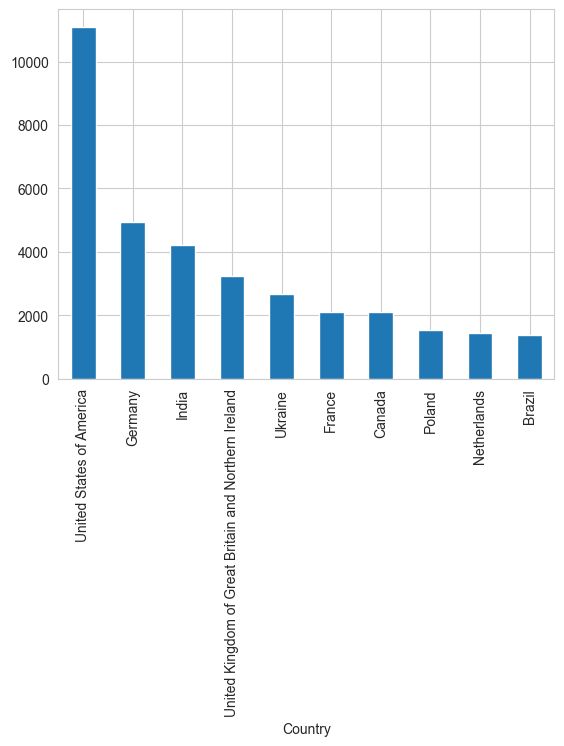

In [11]:
## Write your code here
!pip install matplotlib seaborn

%matplotlib inline 
import matplotlib.pyplot as plt

df['Country'].value_counts().head(10).plot(kind='bar')

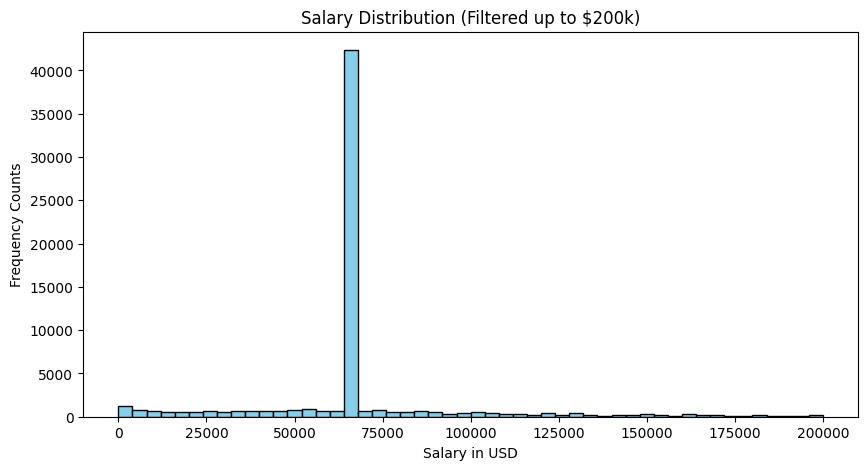

In [101]:
plt.figure(figsize=(10, 5))

plt.hist(df['ConvertedCompYearly'], bins=50, color='skyblue', range=(0, 200000), edgecolor='black')
plt.title('Salary Distribution (Filtered up to $200k)')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency Counts')
plt.show()

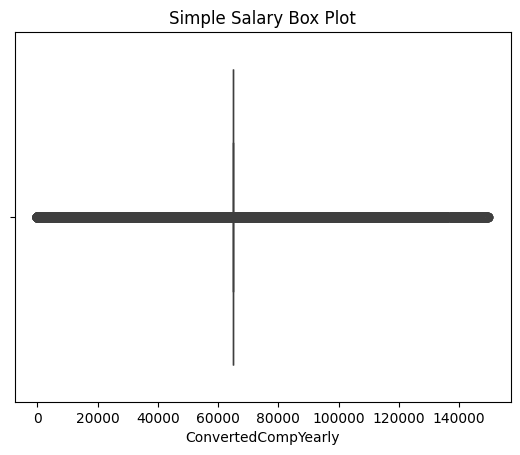

In [97]:
# df['ConvertedCompYearly'].value_counts().head(10).plot(kind='box')
import seaborn as sns

sns.boxplot(x=df[df['ConvertedCompYearly'] < 150000]['ConvertedCompYearly'])


<!--
## Change Log

|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|

--!>


Copyright © IBM Corporation. All rights reserved.
